In [1]:
%load_ext autoreload
%autoreload 2

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance_matrix
from sklearn.manifold import MDS
import torch
from torch.utils.data import DataLoader

In [3]:
from mapcharting.dataset.dataset import CSIPairsDataset
from mapcharting.dissimilarity.dissimilarity import adp_dissimilarity, timestamp_dissimilarity, geodesic_dissimilarity
from mapcharting.loss.loss import siamese_loss
from mapcharting.model.model import ChannelCharter

In [4]:
csi = np.load("data/csi.npz")["arr_0"]
timestamps = np.load("data/timestamps.npz")["arr_0"]
positions = np.load("data/positions.npz")["arr_0"]

In [5]:
device = "mps"
adp_dissimilarity_matrix = adp_dissimilarity(csi, device=device)

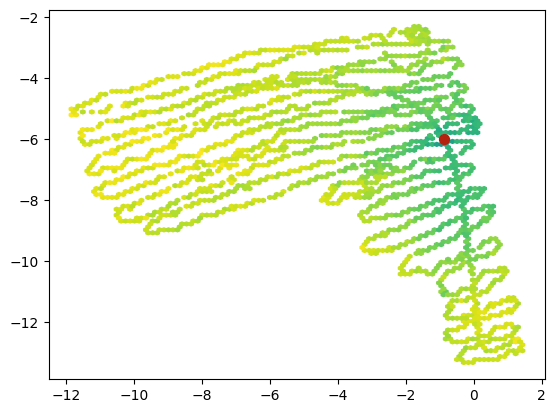

In [17]:
POS = 100

# Hexagonal grid plotting with mp's hexbin
plt.hexbin(positions[:,0], positions[:,1], C=adp_dissimilarity_matrix[POS,:])

# We also mark the position of the reference point
plt.scatter(positions[POS,0], positions[POS,1], s=50, c="#b42210")

In [18]:
timestamp_dissimilarity_matrix = np.abs(np.subtract.outer(timestamps, timestamps))

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_8455/306587099.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_8455/306587099.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)


Text(0, 0.5, 'Number of Occurences')

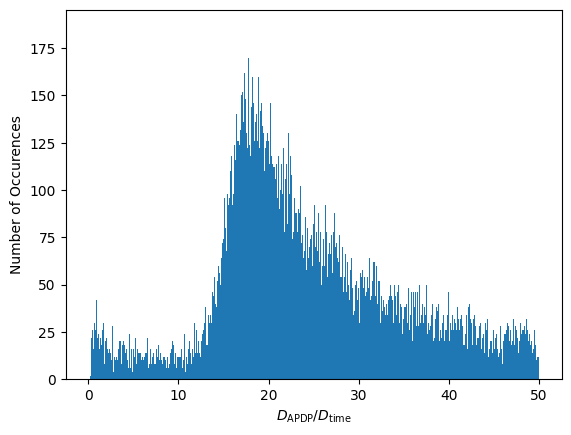

In [19]:
TIME_THRESHOLD = 2
small_time_dissimilarity_indices = np.logical_and(timestamp_dissimilarity_matrix < TIME_THRESHOLD, timestamp_dissimilarity_matrix > 0)
small_time_dissimilarities = timestamp_dissimilarity_matrix[small_time_dissimilarity_indices]
small_adp_dissimilarities = adp_dissimilarity_matrix[small_time_dissimilarity_indices]

n_bins = 1500

fig, ax1 = plt.subplots()
occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)
ax1.set_xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
ax1.set_ylabel("Number of Occurences")

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_8455/4030542455.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")


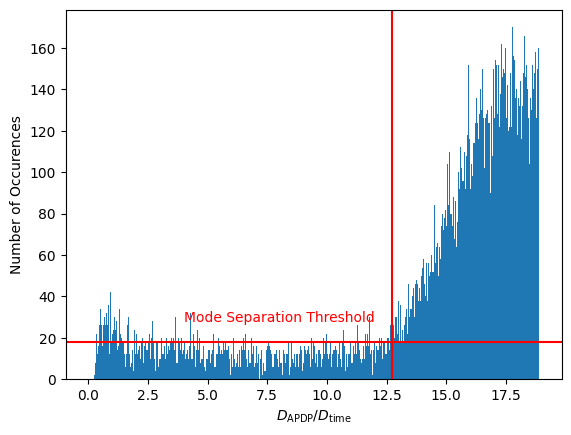

gamma =  12.71666669845581


In [20]:
bin_centers = edges[:-1] + np.diff(edges) / 2.
max_bin = np.argmax(occurences)
min_threshold = np.quantile(occurences[:max_bin], 0.5)

for threshold_bin in range(max_bin - 1, -1, -1):
	if occurences[threshold_bin] < min_threshold:
		break

scaling_factor = bin_centers[threshold_bin]

plt.bar(bin_centers[:max_bin], occurences[:max_bin], width = edges[1] - edges[0])
plt.axhline(y = min_threshold, color = 'r', linestyle = '-')
plt.text(4, min_threshold + 10, "Mode Separation Threshold", color = 'r',)
plt.axvline(x = scaling_factor, color = 'r', linestyle = '-')
plt.xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
plt.ylabel("Number of Occurences")
plt.show()

print("gamma = ", scaling_factor)

In [21]:
dissimilarity_matrix_fused = np.minimum(adp_dissimilarity_matrix, timestamp_dissimilarity_matrix * scaling_factor)

/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_8455/338179116.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dissimilarity_matrix_fused = np.minimum(adp_dissimilarity_matrix, timestamp_dissimilarity_matrix * scaling_factor)


In [22]:
dissimilarity_matrix_geodesic = geodesic_dissimilarity(dissimilarity_matrix=dissimilarity_matrix_fused)

100%|██████████| 4629/4629 [00:11<00:00, 393.23it/s]


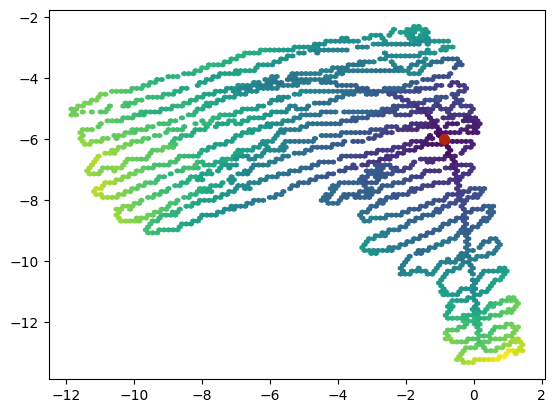

In [23]:
POS = 100

# Hexagonal grid plotting with mp's hexbin
plt.hexbin(positions[:,0], positions[:,1], C=dissimilarity_matrix_geodesic[POS,:])

# We also mark the position of the reference point
plt.scatter(positions[POS,0], positions[POS,1], s=50, c="#b42210")

In [24]:
groundtruth_distance_matrix = distance_matrix(positions, positions)
groundtruth_distance_matrix.shape

(4629, 4629)

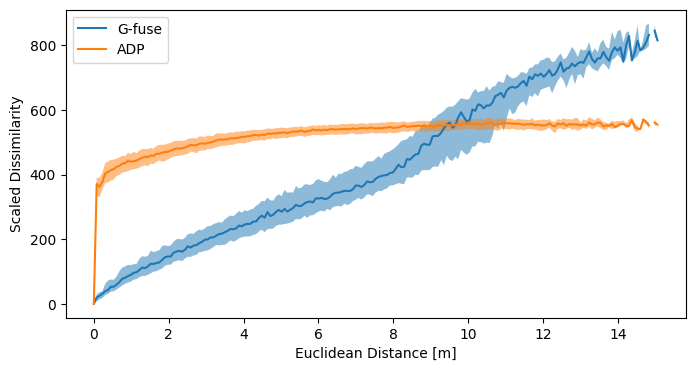

In [25]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label = None):
	nth_reduction = 10
	dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
	distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
	
	max_distance = np.max(distances_flat)
	bins = np.linspace(0, max_distance, 200)
	bin_indices = np.digitize(distances_flat, bins)
	
	bin_medians = np.zeros(len(bins) - 1)
	bin_25_perc = np.zeros(len(bins) - 1)
	bin_75_perc = np.zeros(len(bins) - 1)
	for i in range(1, len(bins)):
		bin_values = dissimilarities_flat[bin_indices == i]
		if len(bin_values) == 0:                                                                                                                                                                        
			bin_25_perc[i - 1] = bin_medians[i - 1] = bin_75_perc[i - 1] = np.nan                                                                                                                       
			continue                                                                                                                                                                                    
		bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75]) 
	
	plt.plot(bins[:-1], bin_medians, label = label)
	plt.fill_between(bins[:-1], bin_25_perc, bin_75_perc, alpha=0.5)
		
plt.figure(figsize=(8,4))

plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix_geodesic, groundtruth_distance_matrix, "G-fuse")
plot_dissimilarity_over_euclidean_distance(scaling_factor * adp_dissimilarity_matrix, groundtruth_distance_matrix, "ADP")

plt.legend()
plt.xlabel("Euclidean Distance [m]")
plt.ylabel("Scaled Dissimilarity")
plt.show()

In [39]:
def plot_colorized(positions, groundtruth_positions, title = None, show = True, alpha = 1.0):
    # Generate RGB colors for datapoints
    center_point = np.zeros(2, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    def NormalizeData(in_data):
        return (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions[:,0:2] - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 1])

    # Plot datapoints
    plt.figure(figsize=(6, 6))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.scatter(positions[:, 0], positions[:, 1], c = rgb_values, alpha = alpha, s = 10, linewidths = 0)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    if show:
        plt.show()

## MDS Solution

/Users/ygglc/Learning/ML/mapcharting/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/ygglc/Learning/ML/mapcharting/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/ygglc/Learning/ML/mapcharting/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/ygglc/Learning/ML/mapcharting/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


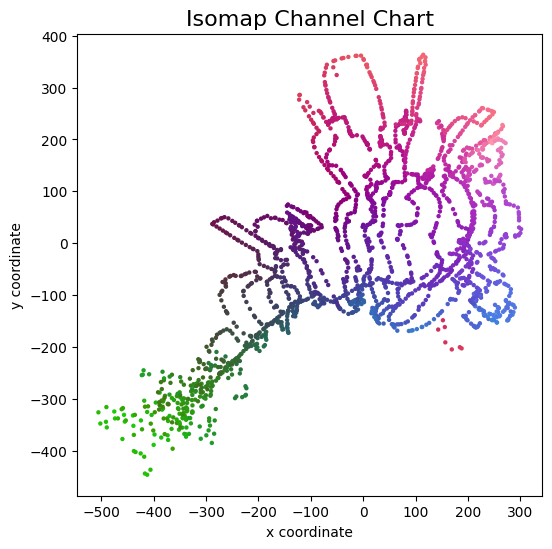

In [43]:
nth_reduction = 2

reduced_dissimilarity_matrix_geodesic = dissimilarity_matrix_geodesic[::nth_reduction, ::nth_reduction]
embedding_isomap = MDS(metric = True, dissimilarity = 'precomputed', max_iter = 80, normalized_stress = False)
proj_isomap = embedding_isomap.fit_transform(reduced_dissimilarity_matrix_geodesic)
plot_colorized(proj_isomap, positions[::nth_reduction], title = "Isomap Channel Chart")

## Deep-Learning based

In [26]:
batch_size = 128
csi_dataset = CSIPairsDataset(csi, dissimilarity_matrix_geodesic)
train_loader = DataLoader(csi_dataset, batch_size=batch_size)

In [46]:
learning_rate = 1e-4
epochs = 300

model = ChannelCharter()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [47]:
model.train()
for i in range(epochs):
    running_loss = 0
    for csi_a, csi_b, dissimilarity in train_loader:
        optimizer.zero_grad()

        oa = model(csi_a) # (batch, 4)
        ob = model(csi_b) # (batch, 4)

        y_pred = torch.cat([oa, ob], dim=1) # (batch, 4)

        loss = siamese_loss(dissimilarity, y_pred, 0.1)
        loss.backward()

        running_loss += loss.item()

        optimizer.step()

    if i % 5 == 0:
        print(f"Epoch: {i} - Loss: {running_loss}")



Epoch: 0 - Loss: 11476.486953735352
Epoch: 5 - Loss: 10919.195602416992
Epoch: 10 - Loss: 10942.770477294922
Epoch: 15 - Loss: 10981.348648071289
Epoch: 20 - Loss: 10506.96565246582
Epoch: 25 - Loss: 10396.354202270508
Epoch: 30 - Loss: 10238.538192749023
Epoch: 35 - Loss: 10169.124893188477
Epoch: 40 - Loss: 10195.711242675781
Epoch: 45 - Loss: 9873.593460083008
Epoch: 50 - Loss: 9850.746826171875
Epoch: 55 - Loss: 9483.142364501953
Epoch: 60 - Loss: 9458.087692260742
Epoch: 65 - Loss: 9211.26693725586
Epoch: 70 - Loss: 9024.594955444336
Epoch: 75 - Loss: 8830.533325195312
Epoch: 80 - Loss: 8675.824844360352
Epoch: 85 - Loss: 8431.274230957031
Epoch: 90 - Loss: 8269.359848022461
Epoch: 95 - Loss: 8062.755661010742
Epoch: 100 - Loss: 7808.303161621094
Epoch: 105 - Loss: 7661.60319519043
Epoch: 110 - Loss: 7528.043869018555
Epoch: 115 - Loss: 7401.78369140625
Epoch: 120 - Loss: 7175.840286254883
Epoch: 125 - Loss: 7125.179336547852
Epoch: 130 - Loss: 6927.458068847656
Epoch: 135 - Loss:

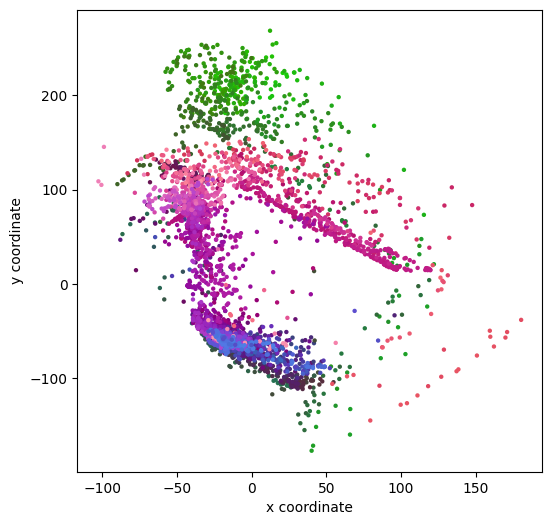

In [48]:
csi_t = torch.from_numpy(csi)

with torch.no_grad():
    model.eval()
    channel_pos = model(csi_t)
    plot_colorized(channel_pos, positions)